<a href="https://colab.research.google.com/github/andresgabas/DS2-Coderhouse/blob/main/DS2%20Pryecto%20final%20Andres%20Gabas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [60]:
url = 'https://raw.githubusercontent.com/andresgabas/DS2-Coderhouse/main/ObesityDataSet_raw_and_data_sinthetic.csv'
data = pd.read_csv(url)
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Abstract
Se trabajará con una base de datos descargada del sitio https://archive.ics.uci.edu/.

Esta base de datos es un .csv que recopila información de obesidad en Mexico, Perú y Colombia haciendo foco en los hábitos alimenticios y en la condición física.

Este trabajo está dirigido a profesionales de la salud del área de la nutrición. El objetivo del trabajo es crear un modelo de Machine learning que a partir de datos de pacientes se los pueda diagnosticar a partir de variables relacionadas con su salud.


Se tuvieron en cuenta las siguientes características para este estudio:

Gender (genero): Masculino o femenino.

Age (edad): Edad de la persona en años.

Height (altura): Altura de la persona en metros.

Weight (peso): Peso de la persona en kg.

Family_history_with_overweight (antecedentes_familiares): antecedentes de obesidad en la familia, si o no.     

FAVC (calorica): comen comida calórica frecuentemente.

FCVC (vegetales): incluyen vegetales en su dieta?

NCP (comidas_principales): Catidad de comidas principales

CAEC (come_entre_comidas): Si comen entre comidas, y la frecuencia.

Smoke (fumador): Si o no.

CH2O (consumo_de_agua): Consumo de agua diario, menos de 1 litros, más de un litro, más de 2 litros

SCC (control_calorias): Control de calorías diario, si o no.

FAF (actividad_fisica) Actividad física, días por semana.

TUE (actividades_sedentarias): cantidad de horas 0 a 2, 3-5, más de 5

CALC (consumo_alcohol): Consume alcohol, no, a veces, frecuentemente o siempre.

MTRANS (medio_de_transporte): Medio de transporte utilizado Auto, moto, bicicleta, transporte público o caminar.  

Nivel de Obesidad (nivel_obesidad): Según peso: peso insuficiente, normal, sobrepeso 1 y 2, obesidad tipo 1, 2 y 3.

Objetivos:

*   Buscar las variables permitan generar un modelos de clasificación que ayuden a clasificar a los diferentes pacientes según su peso.

*   Crear modelos de Machine Learning de aprendizaje supervisado y no supervisado.

*   Buscar las variables que permitan definir un modelo de machine learning de regresión que permita en base a esas características, determinar si un paciente sufre de obesidad o ubicar en que área de peso se encuentra de las
categorías descriptas en la variable nivel_obesidad.

Hipótesis a comprobar:

*   Las personas que más actividad física hacen tienen peso normal.
*   Las personas que comen más vegetales suelen tener peso normal.
*   Las personas que más comidas principales comen son obesas.
*   Las personas que utilizan la bicicleta o caminand como medio de transporte tienen peso normal.

   








In [61]:
data.columns = ['genero','edad','altura','peso','antecedentes','calorica','vegetales','comidas_principales','come_entre_comidas','fumador','consumo_agua','consumo_calorias','actividad_fisica','actividad_sedentaria','consumo_alcohol','medio_de_transporte','nivel_obesidad']

In [62]:
data.describe().round(2)

,edad,altura,peso,vegetales,comidas_principales,consumo_agua,actividad_fisica,actividad_sedentaria
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


En la tabla vemos el resultado del comando describe, este nos permite tener un primer panorama de algunos estadísticos básicos como la media y el desvío estandard. Este nos da una primera impresión de las variables numéricas.

Vamos a revisar si hay datos nulos.

In [63]:
print(data.isnull().sum())

genero                  0
edad                    0
altura                  0
peso                    0
antecedentes            0
calorica                0
vegetales               0
comidas_principales     0
come_entre_comidas      0
fumador                 0
consumo_agua            0
consumo_calorias        0
actividad_fisica        0
actividad_sedentaria    0
consumo_alcohol         0
medio_de_transporte     0
nivel_obesidad          0
dtype: int64


No hay ningún dato nulo.

**Variables categóricas**

Primero se analizarán las variables categóricas.

Text(0.5, 1.0, 'Porcentaje de hombres y mujeres')

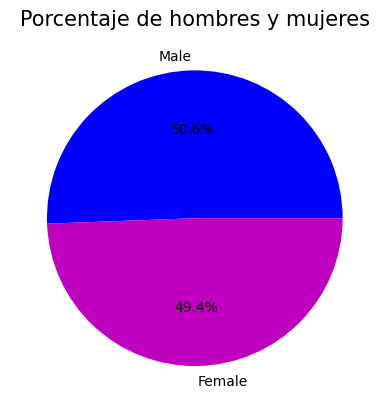

In [64]:
genero_count = data['genero'].value_counts()
plt.pie(genero_count, labels=genero_count.index, autopct='%1.1f%%', colors= ['b','m'])
plt.title('Porcentaje de hombres y mujeres', size=15)

En piechart se observa que la proporción de hombres y mujeres es practicamente similar.

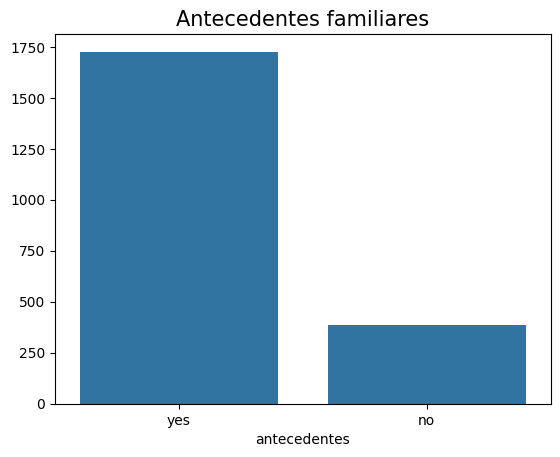

In [65]:
antecedentes_count = data['antecedentes'].value_counts()
sns.barplot(x=antecedentes_count.index, y=antecedentes_count.values)
plt.title('Antecedentes familiares', size=15)
plt.show()

En este gráfico observamos que la mayoría de los participantes tienen antecedentes familiares de obesidad.

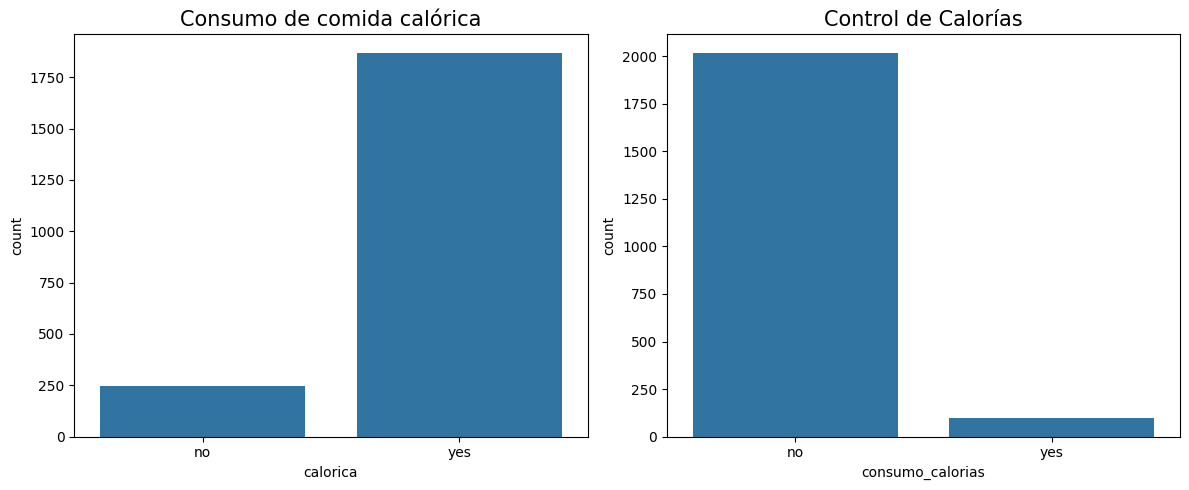

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='calorica', data=data, ax=axes[0])
axes[0].set_title('Consumo de comida calórica', size=15)

sns.countplot(x='consumo_calorias', data=data, ax=axes[1])
axes[1].set_title('Control de Calorías', size=15)

plt.tight_layout()
plt.show()


Estos gráficos se observa que pocos participantes controlan su consumo de calorías y al mismo tiempo son muchos los que consumen comida calórica.

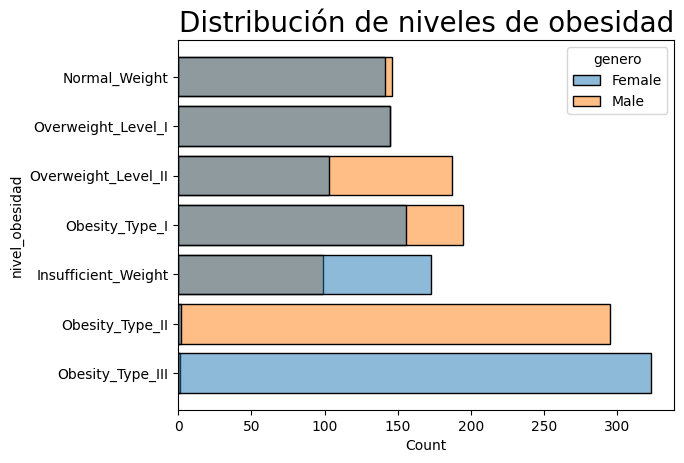

In [67]:
sns.histplot(data=data, y ='nivel_obesidad',shrink=0.8,hue='genero')
plt.title('Distribución de niveles de obesidad', size=20)
plt.show()

En el histograma vemos zonas comunes en gris, naranja para hombres y azul para mujeres, esto es gracias al parámetro hue que nos permite agregar un nivel más de información.

Vemos que las mujeres son mayoría en casi todas las categorías, pero en la categoría de obesidad tipo 3 casi todos son hombres, mientras que en obesidad tipo 2 casi todas son mujeres.

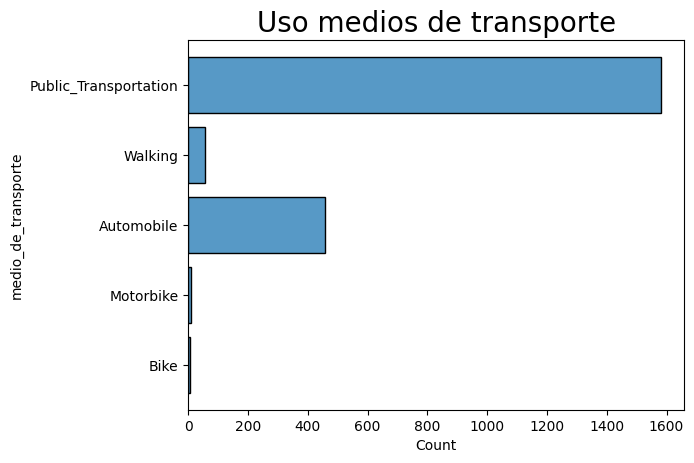

In [68]:
sns.histplot(data=data, y='medio_de_transporte', shrink=0.8)
plt.title('Uso medios de transporte', size=20)
plt.show()

La mayor parte de los participantes utilizan el transporte público o el auto, pero no se ve que caminen o anden en bicicleta que son factores que colaborarían a que no haya obesidad junto con otros hábtos.

Luego de analizar las variables categóricas, creo que se podría generar un modelo de clasificación teniendo en cuenta las variables de control de calorías, consumo de comidas calóricas y medio de transporte utilizado por los encuestados.

Habiendo usado el parámetro hue en varios gráficos no parece ser una variable que me ayude a determinar una diferencia.

**Varianles numéricas**

Para empezar el estudio de las variables numéricas primero realizo una matriz de correlación para ver que variables están correlacionadas.

Luego con la librería seaborn realizo un Heatmap para poder interpretar mejor los resultados obtenidos.

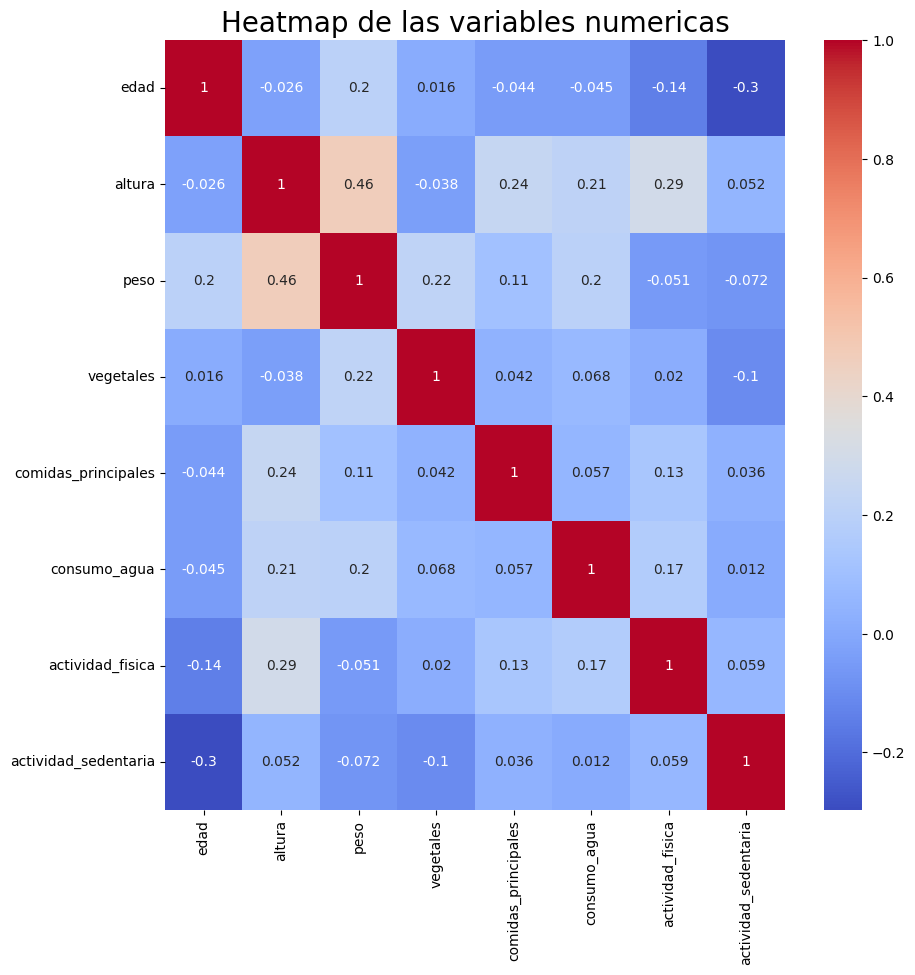

In [69]:
numeric_data = data.select_dtypes(include=['number'])
corr_matrix = numeric_data.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Heatmap de las variables numericas', size=20)
plt.show()


En el heatmap se observa que las variables con mayor correlación son altura y peso. Esto se verificará más adelante en un scartterplot

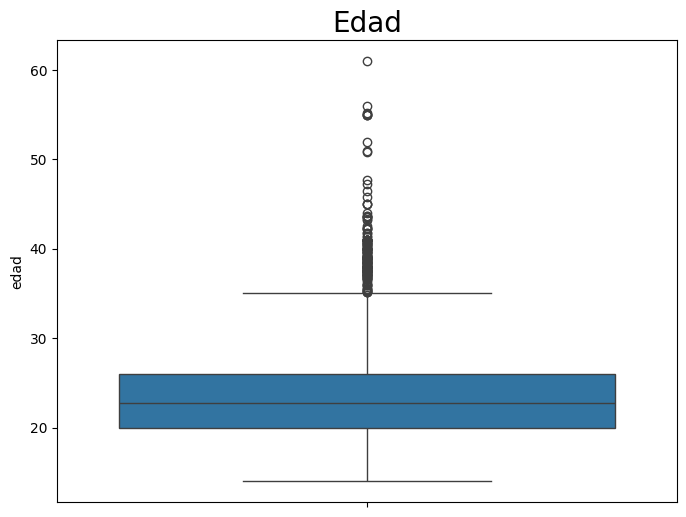

In [70]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=data['edad'])
plt.title('Edad', size=20)
plt.show()

En el boxplot de edad podemos observar que la mayor parte de los encuestados para este estudio se encuentran entre los 20 y los 30 años especialmente cerca de los 20 años. de hecho la media para esta variable es de 24.4 años.

Se observan varios outliers en el gráfico que en realidad no lo son por que son valores de edad lógicos.

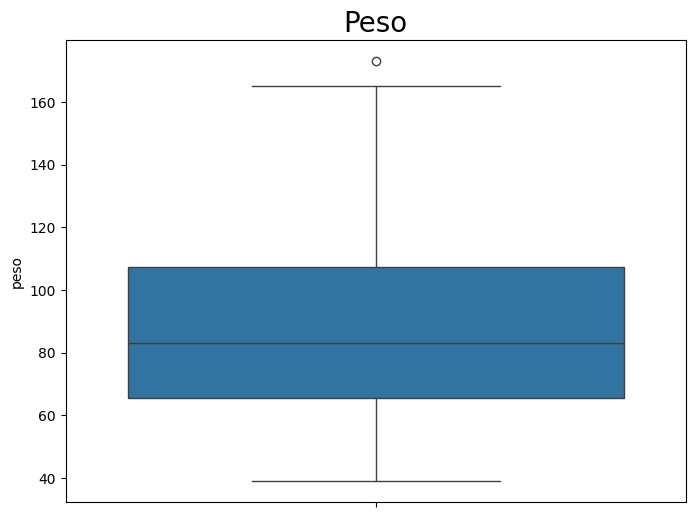

In [71]:
# Boxplot of peso
plt.figure(figsize=(8, 6))
sns.boxplot(y=data['peso'])
plt.title('Peso',size=20)
plt.show()

La mayor parte de los encuestados en el estudio se encuentran en un peso mayor de 60 y menor a 120. Se observan un outlier pero no parece ser un valor de peso ilógico.

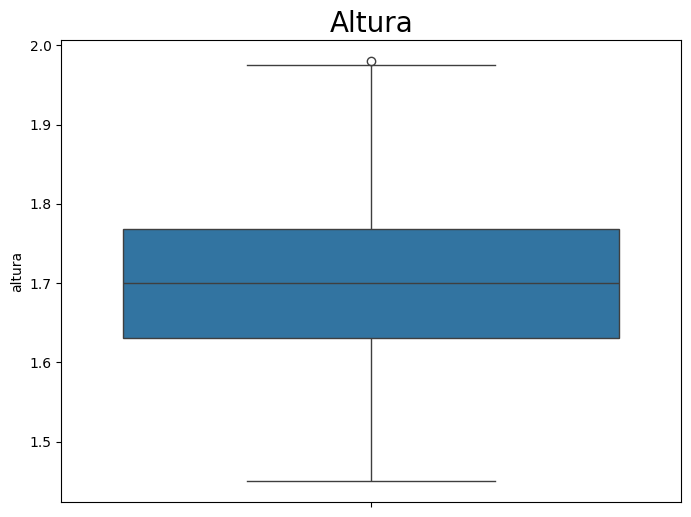

In [72]:
# Boxplot of altura
plt.figure(figsize=(8, 6))
sns.boxplot(y=data['altura'])
plt.title('Altura',size=20)
plt.show()

En el gráfico de altura la mayor parte de los encuestados se encuentran entre 1.60 y 1.80 metros y un solo caso que el boxplot lo marca como outlier que es una altura muy por encima del normal del grupo estudiado.

Text(0.5, 1.0, 'Relación entre altura y peso según nivel de obesidad')

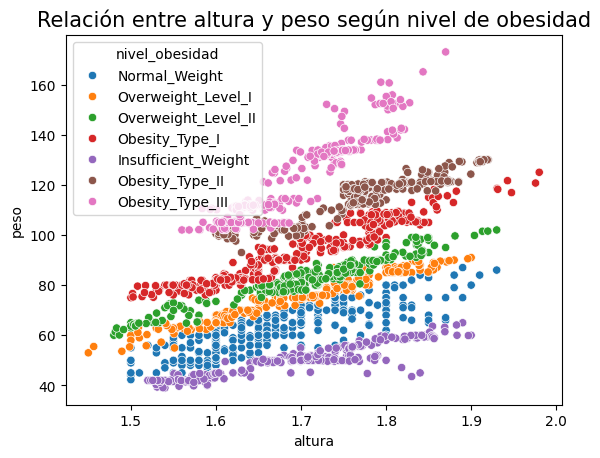

In [73]:
sns.scatterplot(data=data, x="altura", y="peso", hue='nivel_obesidad')
plt.title('Relación entre altura y peso según nivel de obesidad', size=15)

En este gráfico observamos una correlación positiva entre las variables altura y peso, tal como observamos en el heatmap mostrado previamente.

El peso y la altura podrían ser variables candidatas para un modelo de regresión ya que practicamente se distinguen claramente los grupos en estudio.

Creación de los modelos

Luego de realizar el EDA se procedera a trabajar en la creación del modelo para comprobar las hipotesis plateadas previamente.

K Means

El primer modelo que se probará es el modelo no supervisado K Means.

Siempre utilizando las variables altura y peso y la variable target será nivel de obesidad.

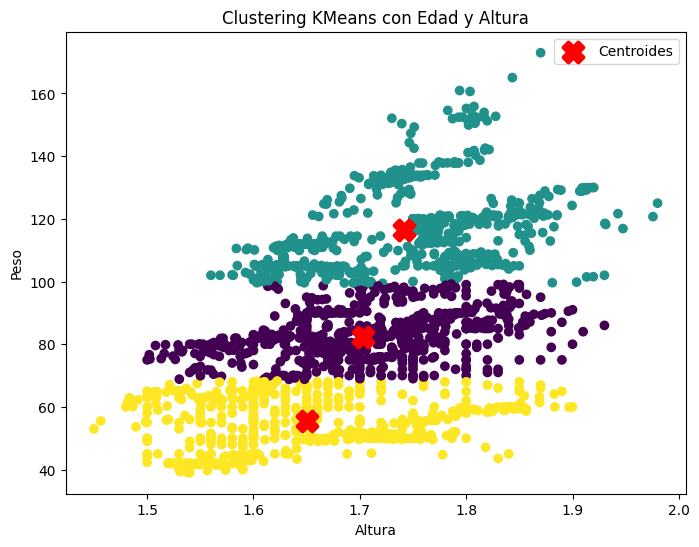

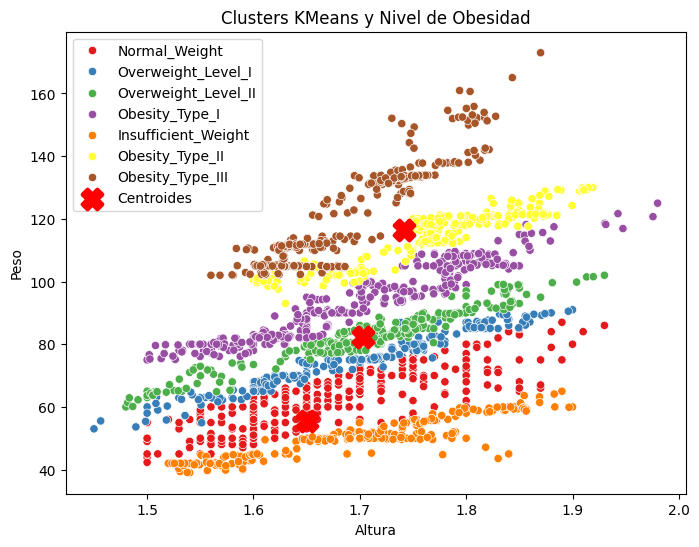

In [98]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Seleccionar las variables predictoras (edad y altura)
X = data[['altura', 'peso']]

# Crear un modelo KMeans con 3 clusters (puedes ajustar el número de clusters)
kmeans = KMeans(n_clusters=3, random_state=42)

# Entrenar el modelo
kmeans.fit(X)

# Obtener las etiquetas de cluster para cada punto de datos
labels = kmeans.labels_

# Obtener las coordenadas de los centroides
centroids = kmeans.cluster_centers_

# Graficar los datos y los clusters
plt.figure(figsize=(8, 6))
plt.scatter(X['altura'], X['peso'], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, linewidths=3, color='r', label='Centroides')
plt.xlabel('Altura')
plt.ylabel('Peso')
plt.title('Clustering KMeans con Peso y Altura')
plt.legend()
plt.show()

# Agregar la columna de etiquetas de cluster al DataFrame
data['cluster'] = labels

# Graficar la variable target (nivel_obesidad) junto con los clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x='altura', y='peso', hue='nivel_obesidad', data=data, palette='Set1')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, linewidths=3, color='r', label='Centroides')
plt.xlabel('Altura')
plt.ylabel('Peso')
plt.title('Clusters KMeans y Nivel de Obesidad')
plt.legend()
plt.show()

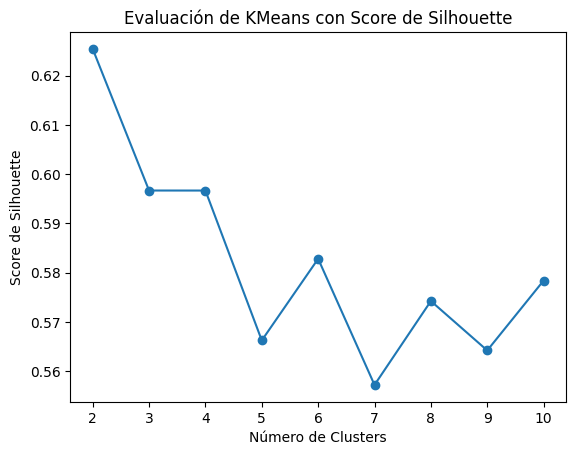

In [97]:
# prompt: Evaluar el modelo k means con el score de silhouette y graficarlo

from sklearn.metrics import silhouette_score

# Seleccionar las variables predictoras (edad y altura)
X = data[['altura', 'peso']]

# Lista para almacenar los scores de silhouette para diferentes números de clusters
silhouette_scores = []

# Iterar sobre un rango de números de clusters
for n_clusters in range(2, 11):  # Puedes ajustar el rango
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X)
    labels = kmeans.labels_
    silhouette_avg = silhouette_score(X, labels)
    silhouette_scores.append(silhouette_avg)

# Graficar los scores de silhouette
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Score de Silhouette')
plt.title('Evaluación de KMeans con Score de Silhouette')
plt.show()

Validación del modelo con LOOCV

In [118]:
# prompt: Validate Kmeans method with LOOCV

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import LeaveOneOut

# ... (Previous code remains the same)

# Prepare data for LOOCV
X = data[['altura', 'peso']]
y = data['nivel_obesidad'] # Assuming 'nivel_obesidad' is your target variable

# Initialize LeaveOneOut
loo = LeaveOneOut()

# Lists to store results
silhouette_scores_loocv = []
predicted_labels_loocv = []

# Perform LOOCV
for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train KMeans model on training set
    kmeans = KMeans(n_clusters=3, random_state=42) # Use optimal k found earlier
    kmeans.fit(X_train)

    # Predict the cluster for the left-out sample
    predicted_label = kmeans.predict(X_test)
    predicted_labels_loocv.append(predicted_label[0]) #Store prediction

    # Calculate silhouette score for the training set in this fold
    labels_train = kmeans.labels_
    silhouette_avg = silhouette_score(X_train, labels_train)
    silhouette_scores_loocv.append(silhouette_avg)

# Analyze results (e.g., calculate average silhouette score)
avg_silhouette_score = np.mean(silhouette_scores_loocv)
print(f"Average Silhouette Score (LOOCV): {avg_silhouette_score}")

#Further analysis of predicted_labels_loocv can be performed here,
#e.g., comparing with the actual 'nivel_obesidad' values in the test folds
#to evaluate the model's performance in a leave-one-out setting.

Average Silhouette Score (LOOCV): 0.5939260671129781


Utilizo

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_search.py:1103: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


Best Hyperparameters: {'init': 'k-means++', 'max_iter': 448, 'n_clusters': 9, 'n_init': 5}
Best Silhouette Score: nan


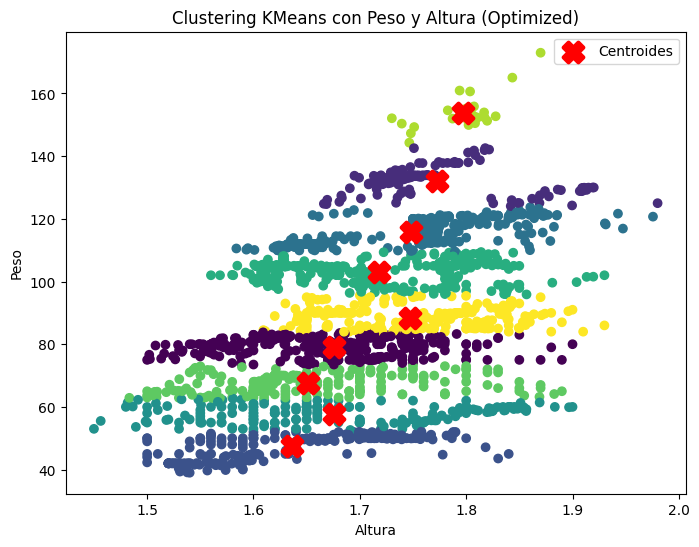

In [117]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import make_scorer, silhouette_score # Import make_scorer

# Define the parameter grid for RandomizedSearchCV
param_dist = {
    'n_clusters': randint(2, 11),  # Number of clusters
    'init': ['k-means++', 'random'], # Initialization method
    'max_iter': randint(100, 500),   # Maximum number of iterations
    'n_init': randint(1, 10)       # Number of times the k-means algorithm will be run with different centroid seeds
}

# Create a KMeans model
kmeans = KMeans(random_state=42)

# Create a silhouette score scorer using make_scorer
silhouette_scorer = make_scorer(silhouette_score) # Create a scorer object

# Create a RandomizedSearchCV object
random_search = RandomizedSearchCV(
    kmeans,
    param_distributions=param_dist,
    n_iter=10, # Number of parameter settings that are sampled
    scoring=silhouette_scorer, # Use the silhouette scorer object
    cv=5, # Number of cross-validation folds
    n_jobs=-1, # Use all available CPU cores
    random_state=42 # Set a random state for reproducibility
)

# Select the features for clustering
X = data[['altura', 'peso']]

# Fit the RandomizedSearchCV object to the data
random_search.fit(X)

# Print the best hyperparameters and the best score
print("Best Hyperparameters:", random_search.best_params_)
print("Best Silhouette Score:", random_search.best_score_)

# Get the best model
best_kmeans = random_search.best_estimator_

# Predict clusters using the best model
labels = best_kmeans.labels_

# Get cluster centroids
centroids = best_kmeans.cluster_centers_

# Plot the results (similar to the previous plot)
plt.figure(figsize=(8, 6))
plt.scatter(X['altura'], X['peso'], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, linewidths=3, color='r', label='Centroides')
plt.xlabel('Altura')
plt.ylabel('Peso')
plt.title('Clustering KMeans con Peso y Altura (Optimized)')
plt.legend()
plt.show()

Modelo de regresión logística

Se creará una variable binaria a partir de la variable target nivel_obesidad, para poder aplicar el modelo de regresión logística.

Para ellos se toman tres tipos de obesidad como 1 y se toman los demás como 0.

In [80]:
data['obesidad_binaria'] = data['nivel_obesidad'].apply(lambda x: 1 if x == 'Obesity_Type_I' or x == 'Obesity_Type_II' or x == 'Obesity_Type_III' else 0)

Defino las variables target x e y

In [96]:
X = data[['peso', 'altura']]
y = data['obesidad_binaria']

In [90]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [91]:
# Create and train the Logistic Regression model
logreg_model = LogisticRegression()
logreg_model.fit(X_train, y_train)

LogisticRegression()

In [92]:
# Make predictions
y_pred = logreg_model.predict(X_test)

In [93]:
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

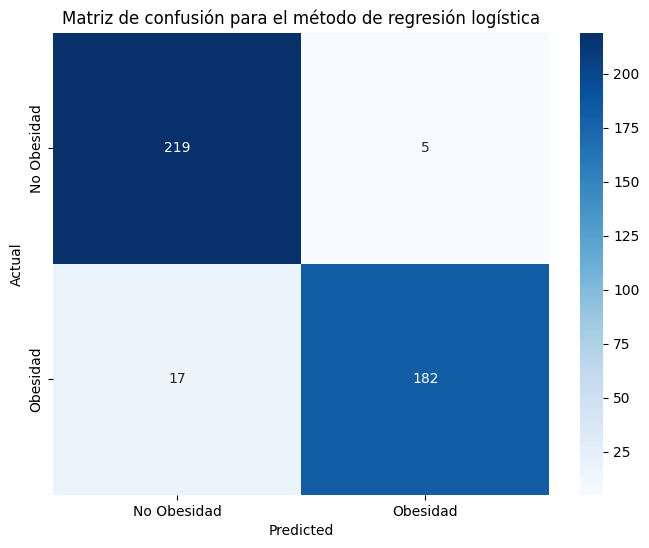

In [94]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Obesidad', 'Obesidad'],
            yticklabels=['No Obesidad', 'Obesidad'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de confusión para el método de regresión logística')
plt.show()

Luego de realizar el modelo de regresión logística se calculan las métricas para evaluar la performance del modelo.

Los valores obtenidos nos indican que el modelo podría predecir de forma correcta si un paciente sufre de obesidad con las variables altura y peso.

In [95]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       224
           1       0.97      0.91      0.94       199

    accuracy                           0.95       423
   macro avg       0.95      0.95      0.95       423
weighted avg       0.95      0.95      0.95       423



In [111]:
# prompt: Validate logistic regression method with LOOCV

from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define the features (X) and target variable (y)
X = data[['peso', 'altura']]
y = data['obesidad_binaria']

# Initialize LeaveOneOut cross-validator
loo = LeaveOneOut()

# Initialize lists to store predictions and true labels
y_pred_loo = []
y_true_loo = []

# Iterate through the folds
for train_index, test_index in loo.split(X):
  # Split data into training and testing sets for the current fold
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  # Train the logistic regression model on the training data
  logreg_model = LogisticRegression()
  logreg_model.fit(X_train, y_train)

  # Make predictions on the test data for the current fold
  y_pred = logreg_model.predict(X_test)

  # Append the prediction and true label to the lists
  y_pred_loo.append(y_pred[0])
  y_true_loo.append(y_test.iloc[0])

# Calculate the accuracy of the model using LOOCV
accuracy = accuracy_score(y_true_loo, y_pred_loo)
print(f"Accuracy with LOOCV: {accuracy}")

Accuracy with LOOCV: 0.9474182851729038


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which 

Best hyperparameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       224
           1       1.00      1.00      1.00       199

    accuracy                           1.00       423
   macro avg       1.00      1.00      1.00       423
weighted avg       1.00      1.00      1.00       423



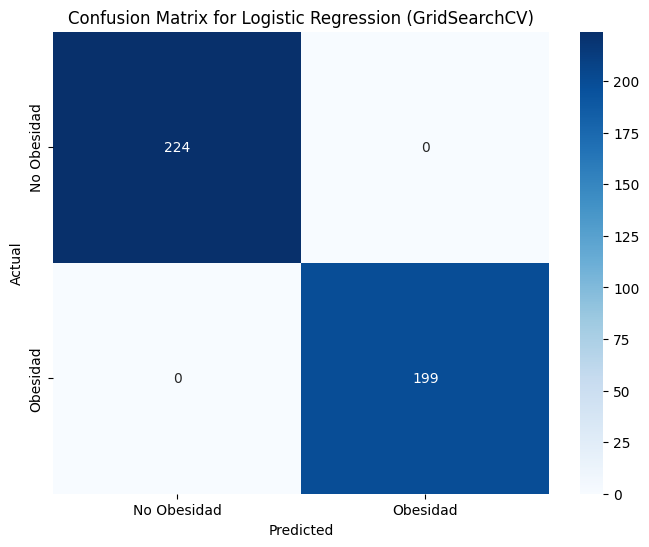

In [112]:
# prompt: Use GridSearchCV to improve logistic regression

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X and y are defined as in the original code
# X = data[['peso', 'altura']]
# y = data['obesidad_binaria']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2'],  # Regularization penalty
    'solver': ['liblinear', 'saga'] # Solvers compatible with both penalties
}


# Initialize Logistic Regression model
logreg_model = LogisticRegression()

# Perform GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(estimator=logreg_model, param_grid=param_grid, cv=5, scoring='accuracy')  # Use 5-fold cross-validation
grid_search.fit(X_train, y_train)

# Get the best model and its hyperparameters
best_logreg_model = grid_search.best_estimator_
print(f"Best hyperparameters: {grid_search.best_params_}")


# Make predictions with the best model
y_pred = best_logreg_model.predict(X_test)

# Evaluate the best model
print(classification_report(y_test, y_pred))

# Create and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Obesidad', 'Obesidad'],
            yticklabels=['No Obesidad', 'Obesidad'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression (GridSearchCV)')
plt.show()